In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
# Step 2: Load Dataset
data = fetch_california_housing()
# Convert to DataFrame (like CSV dataset)
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
print(df.head())
# Step 3: Define Features and Target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [ ]:
# Step 1: Select ONE feature
X_single = df[["MedInc"]]   # Only one independent variable
y = df["MedHouseVal"]
# Step 2: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42)
# Step 3: Train Model
from sklearn.linear_model import LinearRegression
linear_single = LinearRegression()
linear_single.fit(X_train, y_train)
# Step 4: Predict
y_pred_single = linear_single.predict(X_test)
# Step 5: Evaluate
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
print("Simple Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_single))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_single)))

Simple Linear Regression
R2 Score: 0.45885918903846656
RMSE: 0.8420901241414455


In [ ]:
linear = LinearRegression()
linear.fit(X_train, y_train)
y_pred_linear = linear.predict(X_test)
print("Multiple Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print()

Multiple Linear Regression
R2 Score: 0.45885918903846656
RMSE: 0.8420901241414455



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
# Predict
y_pred_poly = poly_model.predict(X_test_poly)
print("Polynomial Regression (Degree 2)")
print("R2 Score:", r2_score(y_test, y_pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Polynomial Regression (Degree 2)
R2 Score: 0.46331772769346224
RMSE: 0.8386138969115731


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print("Ridge Regression")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print()

Ridge Regression
R2 Score: 0.4588594594073131
RMSE: 0.8420899137757148



In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print("Lasso Regression")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso Regression
R2 Score: 0.457868773280494
RMSE: 0.8428603839770815


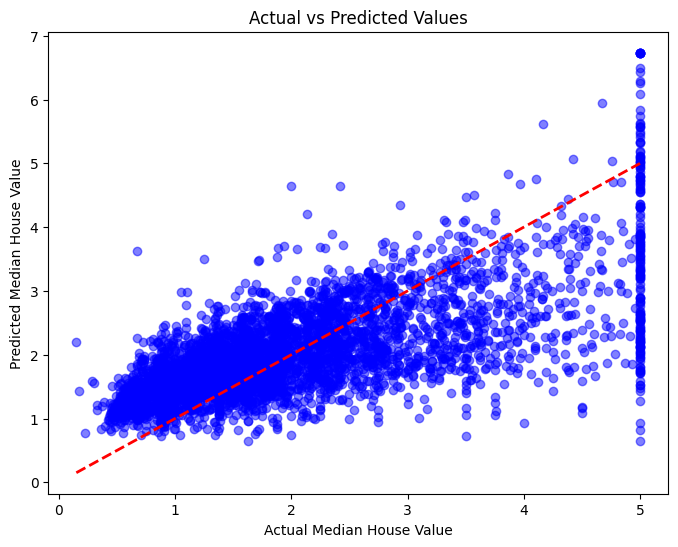

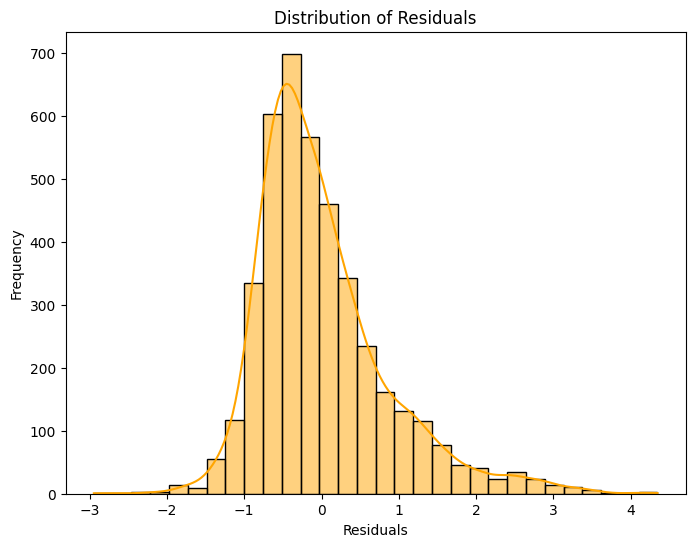

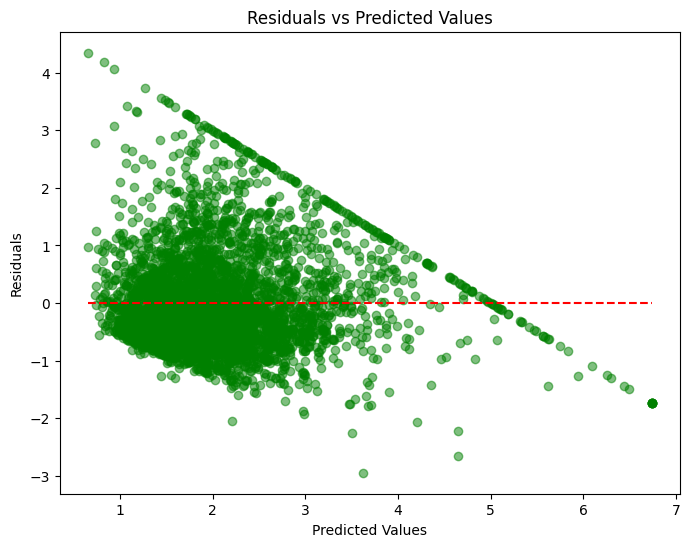

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = y_pred_ridge

# Step 1: Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values")
plt.show()

# Step 2: Residuals Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color="orange")
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Step 3: Residuals vs Predicted Values
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5, color="green")
plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), colors='r', linestyles='dashed')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()